<a href="https://colab.research.google.com/github/dsharma44418-ai/CELEBAL_INTERNSHIP/blob/main/Week3_Dheeraj_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Country-data.csv')

# Display the first 5 rows
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


1:Check Data Info and Missing Values

In [2]:
# Check dataset information
print(df.info())

# Check for missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


2:Data Preprocessing & Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

# Drop categorical 'country' column for clustering
X = df.drop(columns=['country'])

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3:K-Means Clustering (Finding optimal clusters using Elbow Method)

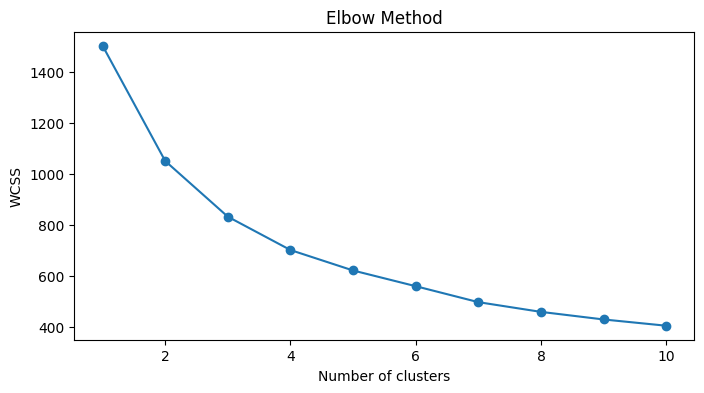

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Elbow method to find best number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Fit K-Means with optimal clusters (let's say 3 based on country data)
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Labels'] = kmeans_model.fit_predict(X_scaled)

4:DBSCAN Clustering

In [6]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=2.5, min_samples=3)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_scaled)

# Check the cluster distribution
print("KMeans Cluster Distribution:\n", df['KMeans_Labels'].value_counts())
print("\nDBSCAN Cluster Distribution:\n", df['DBSCAN_Labels'].value_counts())

KMeans Cluster Distribution:
 KMeans_Labels
2    84
1    47
0    36
Name: count, dtype: int64

DBSCAN Cluster Distribution:
 DBSCAN_Labels
 0    161
-1      6
Name: count, dtype: int64


5:Classification using Ensemble Models (Random Forest & XGBoost)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features and target (using KMeans labels as target)
X_train_features = X_scaled
y_target = df['KMeans_Labels']

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_train_features, y_target, test_size=0.2, random_state=42)

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

# 2. XGBoost Classifier
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("\n--- XGBoost Performance ---")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

--- Random Forest Performance ---
Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


--- XGBoost Performance ---
Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      1.00      0.92         6
           2       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34

